In [ ]:
!pip install -q ultralytics kaggle

import os
import yaml
import shutil
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print('Setup complete.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup complete.


In [ ]:
from google.colab import files

uploaded = files.upload()  # select archive.zip here
zip_name = list(uploaded.keys())[0]
print('Uploaded:', zip_name)

Saving archive.zip to archive.zip
Uploaded: archive.zip


In [ ]:
os.makedirs('/content/data', exist_ok=True)
!unzip -q -o "{zip_name}" -d /content/data

# Inspect what we got
for p in Path('/content/data').rglob('*'):
    if p.is_dir():
        print(p)

/content/data/valid
/content/data/train
/content/data/valid/valid
/content/data/train/train
/content/data/valid/valid/images
/content/data/valid/valid/labels
/content/data/train/train/images
/content/data/train/train/labels


In [ ]:
data_root = Path('/content/data')

train_img_dir = data_root / 'train' / 'train' / 'images'
val_img_dir = data_root / 'valid' / 'valid' / 'images'

assert train_img_dir.exists(), f'Missing {train_img_dir} — check the printed folder tree above'
assert val_img_dir.exists(), f'Missing {val_img_dir} — check the printed folder tree above'

class_names = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

data_yaml = {
    'train': str(train_img_dir),
    'val': str(val_img_dir),
    'nc': len(class_names),
    'names': class_names,
}

data_yaml_path = '/content/data/data.yaml'
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print('Built data.yaml:')
print(Path(data_yaml_path).read_text())

Built data.yaml:
names:
- crazing
- inclusion
- patches
- pitted_surface
- rolled-in_scale
- scratches
nc: 6
train: /content/data/train/train/images
val: /content/data/valid/valid/images



In [ ]:
MODEL_SIZES = ['n', 's', 'm', 'l']  # nano, small, medium, large
EPOCHS = 50
IMG_SIZE = 640

results_summary = {}

for size in MODEL_SIZES:
    print(f'\n=== Training YOLOv8{size} ===')
    model = YOLO(f'yolov8{size}.pt')
    run_name = f'yolov8{size}_neu'

    model.train(
        data=data_yaml_path,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        name=run_name,
        patience=15,
        exist_ok=True,
    )

    metrics = model.val(data=data_yaml_path, name=f'{run_name}_val', exist_ok=True)

    results_summary[size] = {
        'precision': float(metrics.box.mp),
        'recall': float(metrics.box.mr),
        'map50': float(metrics.box.map50),
        'map50_95': float(metrics.box.map),
        'run_dir': f'runs/detect/{run_name}',
        'weights': f'runs/detect/{run_name}/weights/best.pt',
    }

print('\nAll training runs complete.')


=== Training YOLOv8n ===
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_neu, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

KeyboardInterrupt: 

In [ ]:
import pandas as pd

df = pd.DataFrame(results_summary).T
df.index.name = 'model_size'
df = df[['precision', 'recall', 'map50', 'map50_95']]
print(df.to_string())

best_size = df['map50_95'].astype(float).idxmax()
print(f'\nBest model by mAP@50-95: YOLOv8{best_size}')
print(df.loc[best_size])

           precision    recall     map50  map50_95
model_size                                        
n           0.648589  0.778601  0.798925  0.492953
s           0.574725  0.820678   0.79771  0.489096
m           0.714556  0.735205  0.806813  0.481158

Best model by mAP@50-95: YOLOv8n
precision    0.648589
recall       0.778601
map50        0.798925
map50_95     0.492953
Name: n, dtype: object


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
best_weights_src = results_summary[best_size]['weights']
final_best_path = '/content/best.pt'
shutil.copy(best_weights_src, final_best_path)
print(f'Saved best model (YOLOv8{best_size}) to {final_best_path}')

# Download to your machine
files.download(final_best_path)

Saved best model (YOLOv8n) to /content/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

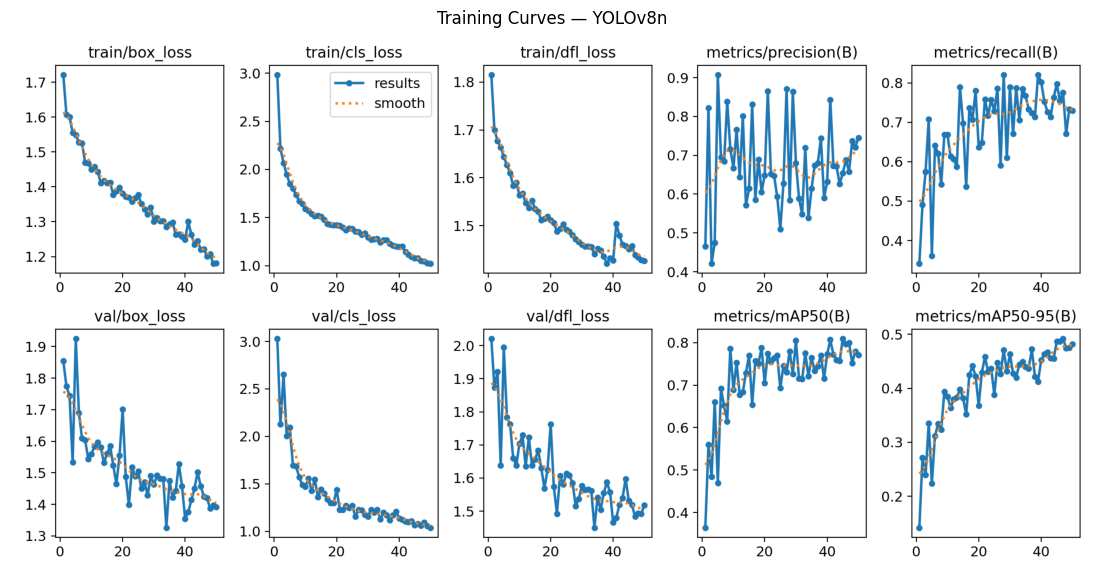

In [ ]:
best_run_dir = results_summary[best_size]['run_dir']

img = mpimg.imread(f'{best_run_dir}/results.png')
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f'Training Curves — YOLOv8{best_size}')
plt.show()

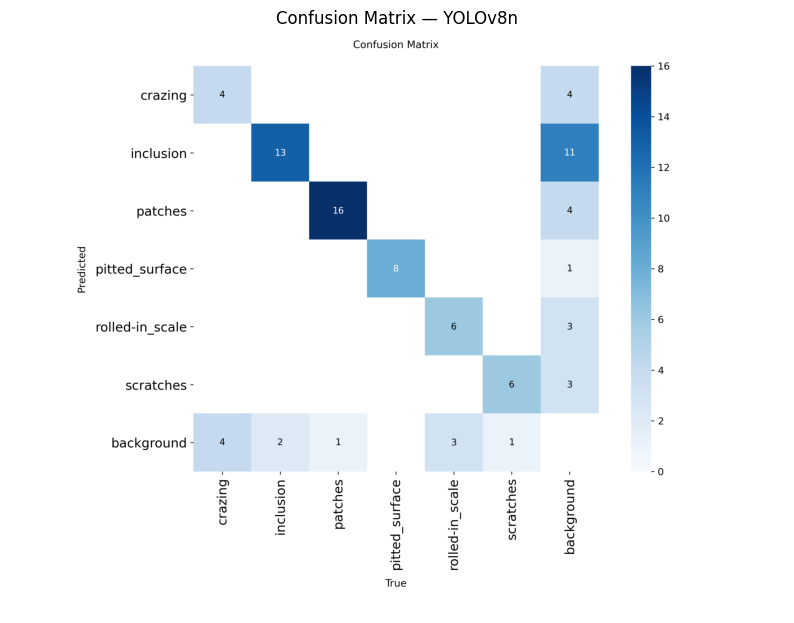

In [ ]:
img = mpimg.imread(f'{best_run_dir}/confusion_matrix.png')
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f'Confusion Matrix — YOLOv8{best_size}')
plt.show()


0: 640x640 6 inclusions, 7.3ms
1: 640x640 3 inclusions, 7.3ms
2: 640x640 2 patchess, 7.3ms
3: 640x640 1 crazing, 7.3ms
4: 640x640 2 rolled-in_scales, 7.3ms
5: 640x640 3 patchess, 7.3ms
Speed: 2.4ms preprocess, 7.3ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


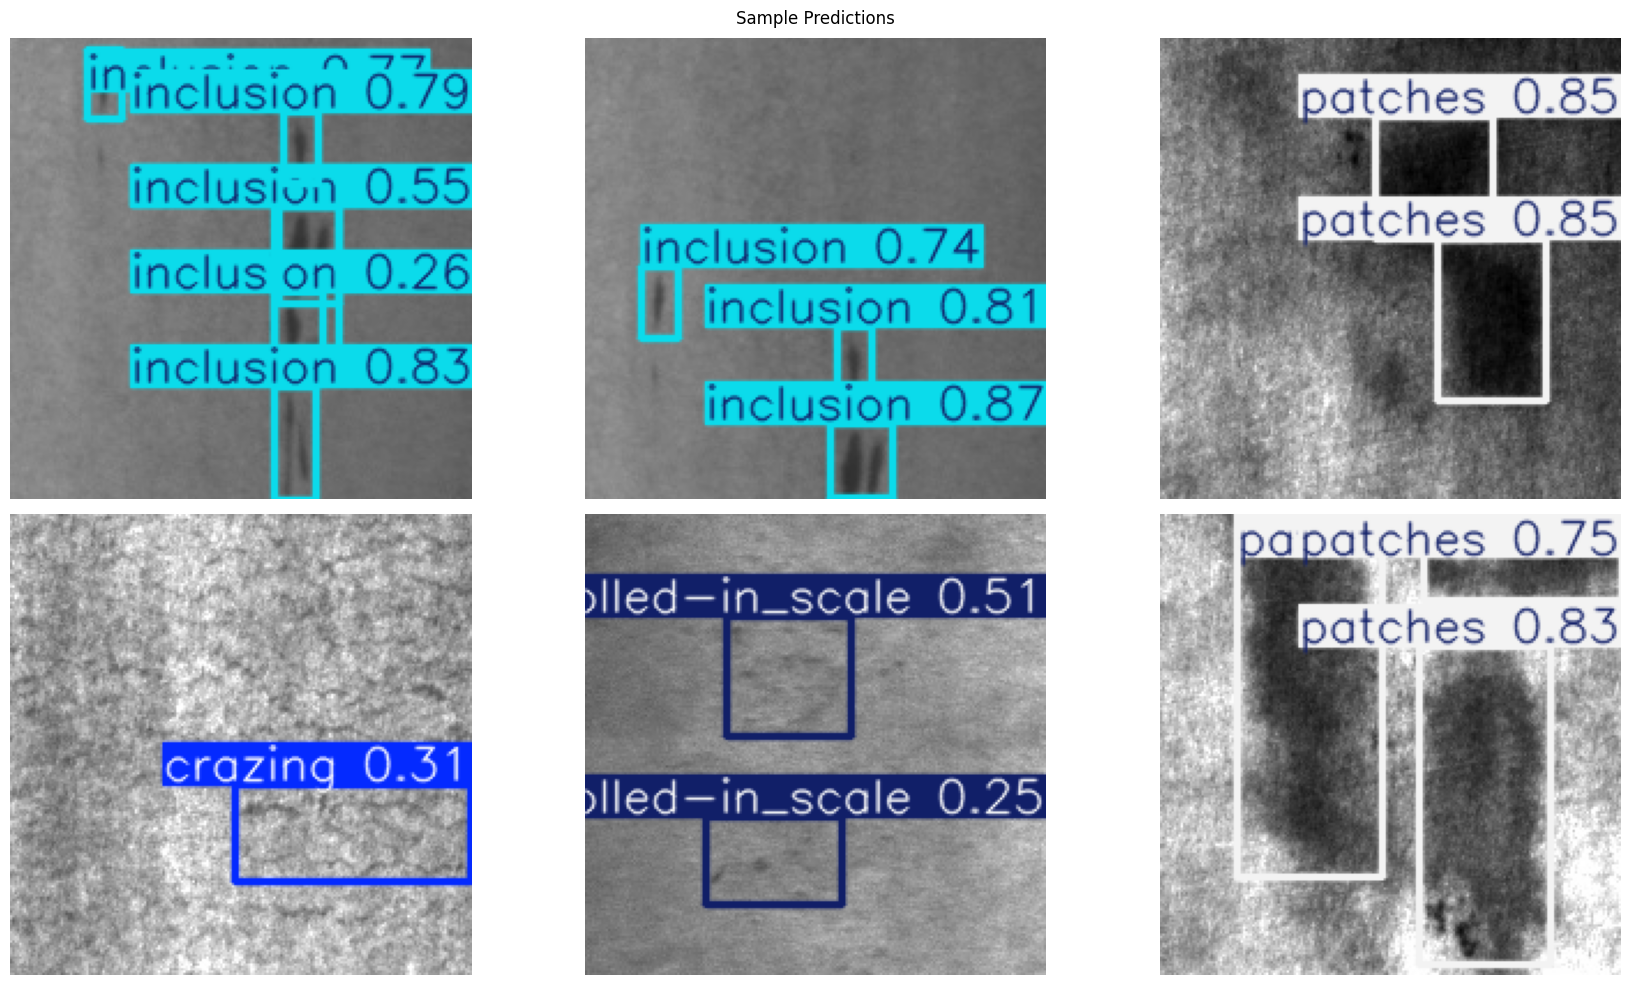

In [ ]:
best_model = YOLO(final_best_path)

val_dir = Path(yaml.safe_load(Path(data_yaml_path).read_text())['val'])
sample_images = list(val_dir.rglob('*.jpg'))[:6] or list(val_dir.rglob('*.png'))[:6]

pred_results = best_model.predict(source=sample_images, save=True, conf=0.25)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, res in zip(axes.flatten(), pred_results):
    ax.imshow(res.plot()[:, :, ::-1])  # BGR -> RGB
    ax.axis('off')
plt.suptitle('Sample Predictions')
plt.tight_layout()
plt.show()

In [ ]:
final = results_summary[best_size]
print(f"Best model: YOLOv8{best_size}")
print(f"Precision : {final['precision']:.3f}")
print(f"Recall    : {final['recall']:.3f}")
print(f"mAP@50    : {final['map50']:.3f}")
print(f"mAP@50-95 : {final['map50_95']:.3f}")

Best model: YOLOv8n
Precision : 0.649
Recall    : 0.779
mAP@50    : 0.799
mAP@50-95 : 0.493
